# Valid Frames

This notebook checks the valid frames for responses and videos across recordings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet

Define the paths used to access data and metadata.

In [2]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
]

Initialize a `DataSet` object to handle the full dataset.

In [3]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             check=False,
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()

# Mapping from recording name to rec-animalID-session-scan format
mapping = {}
for rec in ds.recording:
    x = rec.split("-")
    mapping[rec] = f"rec-{ds.info[rec]['animal_id']}-{ds.info[rec]['session']}-{ds.info[rec]['scan_idx']}"



Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce from metadata
 > Loading neurons fo

## Differences in valid frames

See how many trials there are per recording with a different number of valid frames between the video and the response

In [4]:
trials_df["valid_frames_diff"] = trials_df["valid_frames_video"] - trials_df["valid_frames_response"]
result = (
    trials_df.groupby("recording")["valid_frames_diff"]
    .apply(lambda x: {
        "video>response": (x > 0).sum(),
        "response>video": (x < 0).sum(),
        "equal":     (x == 0).sum()
    })
    .apply(pd.Series)
    .reset_index()
)
result.columns = ["recording", "relation", "count"]
result


,recording,relation,count
0,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,video>response,0
1,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,response>video,0
2,dynamic29156-11-10-Video-8744edeac3b4d1ce16b68...,equal,720
3,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,video>response,0
4,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,response>video,0
5,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,equal,704
6,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,video>response,0
7,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,response>video,0
8,dynamic29234-6-9-Video-8744edeac3b4d1ce16b6809...,equal,729
9,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,video>response,0


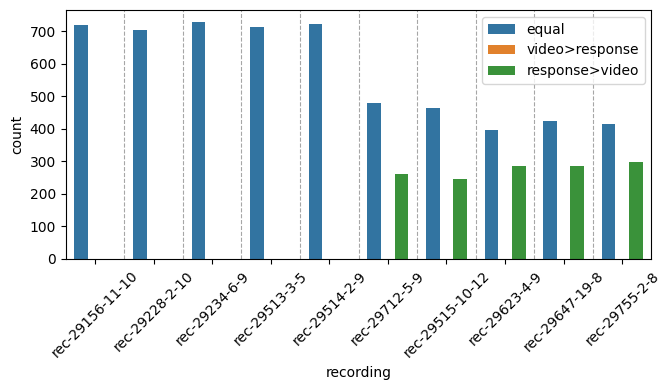

In [25]:
result["recording_short_label"] = result["recording"].map(mapping)
rec_order = [mapping[rec] for rec in all_recording_folders]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=result, x="recording_short_label", y="count", hue="relation", order=rec_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.7)
ax.tick_params(axis='x', rotation=45)
ax.set_xlabel("recording")
ax.legend()
# Add vertical lines between x groups
n_groups = len(result["recording_short_label"].unique())
for i in range(n_groups - 1):
    ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

fig.tight_layout(rect=[0, 0, 0.85, 1])
fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-recording.png"), dpi=300)
plt.show()


In [11]:
min_diff = np.min(trials_df["valid_frames_diff"].to_numpy())
max_diff = np.max(trials_df["valid_frames_diff"].to_numpy())
print(f"range for valid_frames_diff [{min_diff}, {max_diff}]")

range for valid_frames_diff [-114, 0]


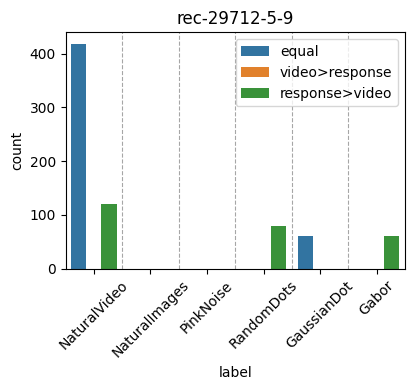

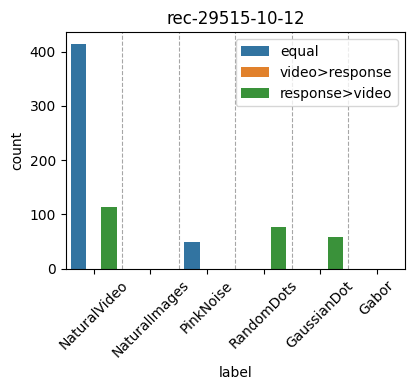

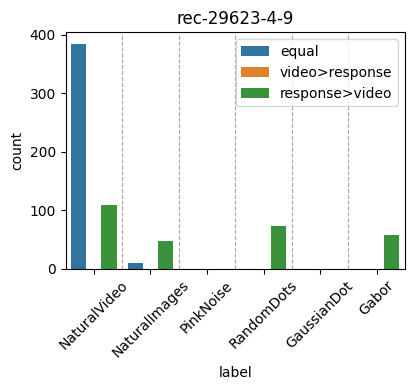

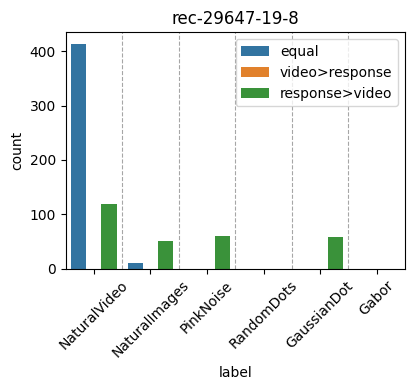

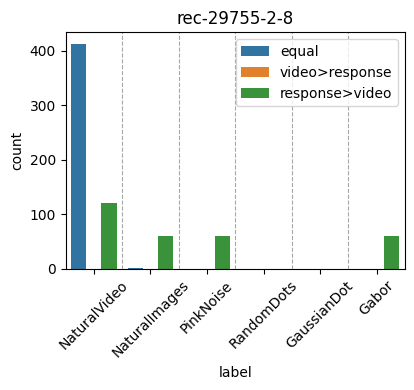

In [23]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
for rec in ds.recording:
    df = trials_df[trials_df['recording']==rec]
    if any(df["valid_frames_diff"]!=0):
        result_rec = (
        df.groupby("label")["valid_frames_diff"]
        .apply(lambda x: {
            "video>response": (x > 0).sum(),
            "response>video": (x < 0).sum(),
            "equal":     (x == 0).sum()
        })
        .apply(pd.Series)
        .reset_index()
        )
        result_rec.columns = ["label", "relation", "count"]

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.barplot(data=result_rec, x="label", y="count", hue="relation", order=labels_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.8)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel("label")
        ax.legend()
        ax.set_title(mapping[rec])
        # Add vertical lines between x groups
        n_groups = len(labels_order)
        for i in range(n_groups - 1):
            ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

        fig.tight_layout(rect=[0, 0, 0.85, 1])
        fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-label_rec-{mapping[rec]}.png"), dpi=300)
        plt.show()

   
    

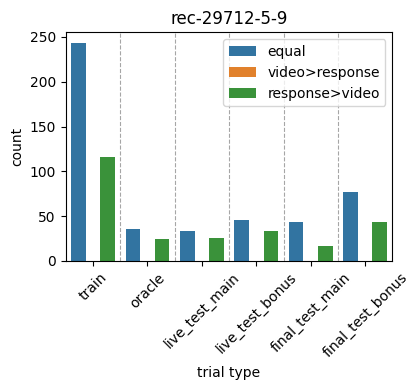

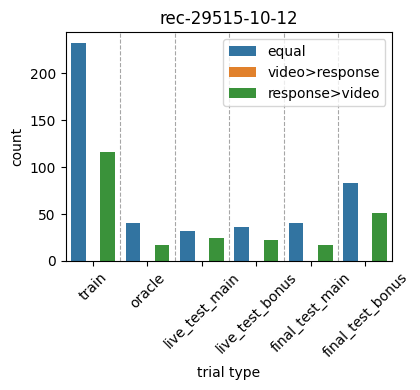

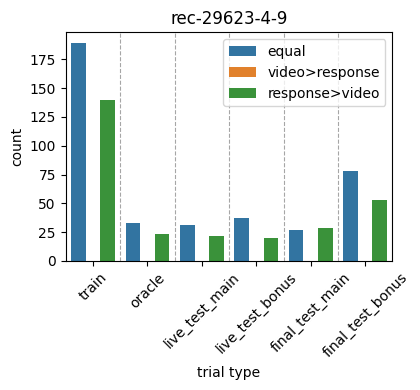

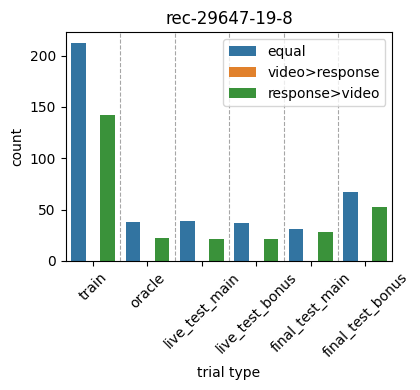

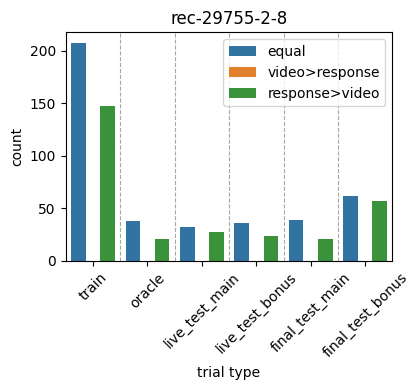

In [26]:
labels_order=["NaturalVideo", "NaturalImages", "PinkNoise","RandomDots","GaussianDot","Gabor"]
trials_order = ["train", "oracle","live_test_main","live_test_bonus","final_test_main","final_test_bonus"]

for rec in ds.recording:
    df = trials_df[trials_df['recording']==rec]
    if any(df["valid_frames_diff"]!=0):
        result_rec = (
        df.groupby("trial_type")["valid_frames_diff"]
        .apply(lambda x: {
            "video>response": (x > 0).sum(),
            "response>video": (x < 0).sum(),
            "equal":     (x == 0).sum()
        })
        .apply(pd.Series)
        .reset_index()
        )
        result_rec.columns = ["trial_type", "relation", "count"]

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.barplot(data=result_rec, x="trial_type", y="count", hue="relation", order=trials_order, hue_order=["equal","video>response","response>video"], ax=ax, width=0.8)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel("trial type")
        ax.legend()
        ax.set_title(mapping[rec])
        # Add vertical lines between x groups
        n_groups = len(trials_order)
        for i in range(n_groups - 1):
            ax.axvline(x=i + 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

        fig.tight_layout(rect=[0, 0, 0.85, 1])
        fig.savefig(Path(repo_root, 'figures', f"valid-frames_x-trial-type_rec-{mapping[rec]}.png"), dpi=300)
        plt.show()


## Trials with same ID and different valid frames

### For the trial valid frames

In [37]:
result_trials = trials_df.groupby("ID")["valid_frames"].nunique()
result_trials = result_trials.reset_index()
result_trials.columns = ["ID", "count"]
result_trials.loc[result_trials["count"]>1]


,ID,count
180,v089720,2
688,v360898,2
1321,v683710,2
1708,v874315,2


### For the video valid frames

In [38]:
result_video = trials_df.groupby("ID")["valid_frames_video"].nunique()
result_video = result_video.reset_index()
result_video.columns = ["ID", "count"]
result_video.loc[result_video["count"]>1]


,ID,count
180,v089720,2
688,v360898,2
1321,v683710,2
1708,v874315,2


### For the response valid frames

In [39]:
result_resp = trials_df.groupby("ID")["valid_frames_response"].nunique()
result_resp = result_resp.reset_index()
result_resp.columns = ["ID", "count"]
result_resp.loc[result_resp["count"]>1]

,ID,count
4,v001927,2
6,v002231,2
32,v017876,2
40,v022890,2
49,v028823,2
...,...,...
1850,v929537,2
1864,v936407,2
1910,v967131,2
1926,v975560,2


### Inspect some videos with same ID and different valid frames

In [44]:
ID = "v089720"
df_filtered = ds.filter_trials(ID=ID)
df_filtered

,recording,label,ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_diff
2191,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,716,train,310,True,310,310,0
2214,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,671,final_test_bonus,310,True,310,310,0
2223,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,678,train,310,True,310,310,0
2274,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,687,train,311,True,311,311,0
2283,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,673,final_test_bonus,310,True,310,310,0
2321,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,703,oracle,310,True,310,310,0
2356,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,698,train,310,True,310,310,0
2383,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,718,final_test_bonus,310,True,310,310,0
2543,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,688,final_test_main,310,True,310,310,0
2667,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,677,train,310,True,310,310,0


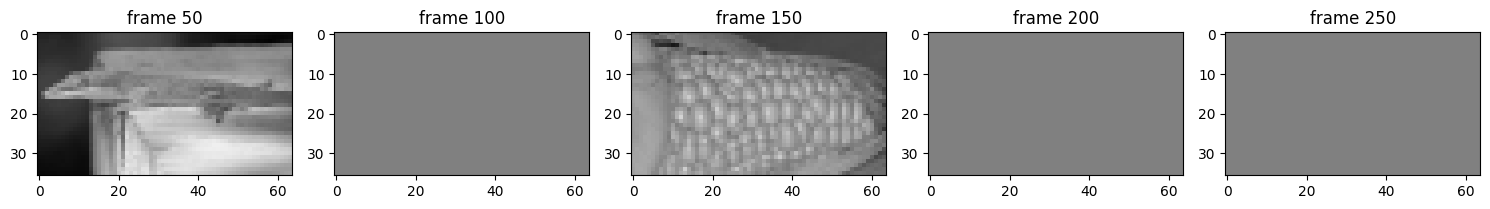

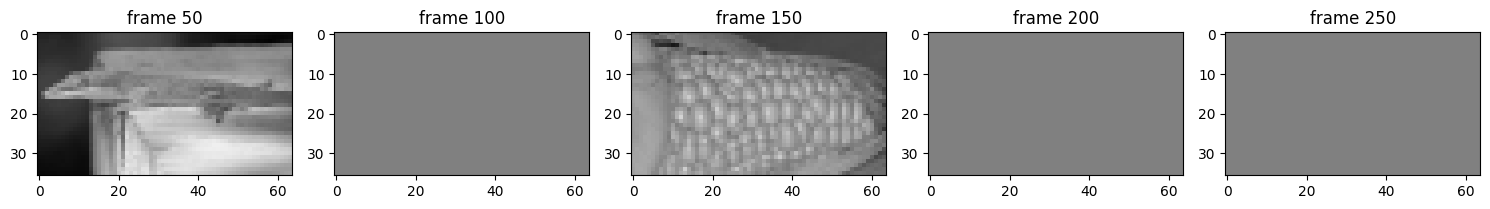

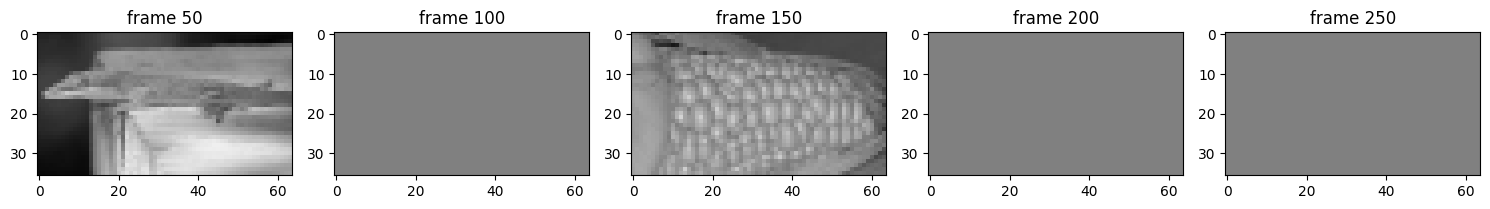

In [ ]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='716', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='687', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='118', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)


In [54]:
ID = "v360898"
df_filtered = ds.filter_trials(ID=ID)
df_filtered

,recording,label,ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_diff
2210,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,660,oracle,313,True,313,313,0
2278,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,661,train,313,True,313,313,0
2340,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,665,live_test_main,313,True,313,313,0
2378,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,683,final_test_bonus,313,True,313,313,0
2612,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,715,train,313,True,313,313,0
2649,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,707,final_test_bonus,312,True,312,312,0
2650,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,697,train,313,True,313,313,0
2681,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,695,live_test_main,312,True,312,312,0
2775,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,701,train,313,True,313,313,0
2825,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,684,live_test_bonus,313,True,313,313,0


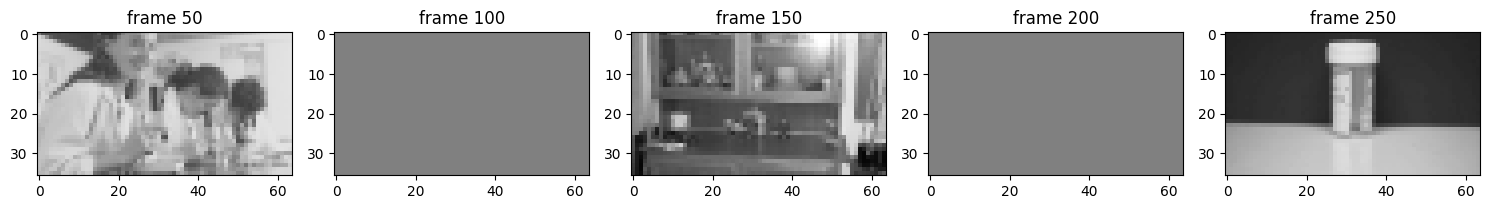

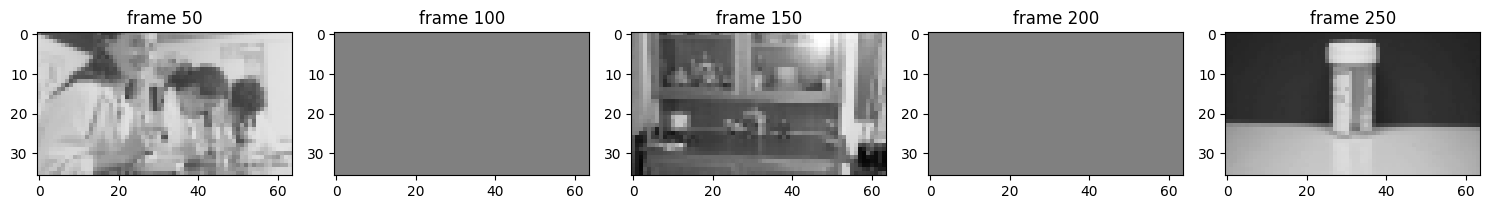

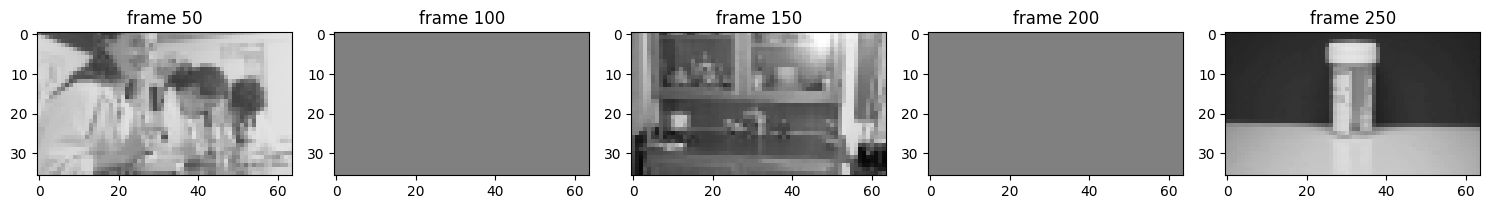

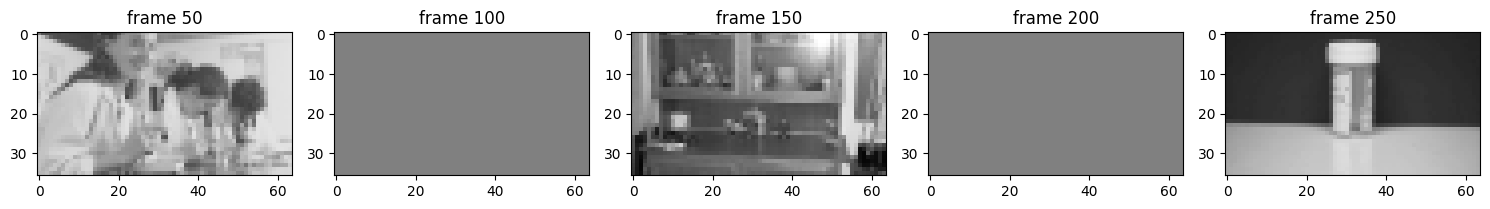

In [55]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='660', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='707', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='209', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='49', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)

In [56]:
ID = "v683710"
df_filtered = ds.filter_trials(ID=ID)
df_filtered

,recording,label,ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_diff
2225,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,708,train,319,True,319,319,0
2236,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,672,train,319,True,319,319,0
2298,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,666,train,319,True,319,319,0
2320,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,692,final_test_bonus,319,True,319,319,0
2447,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,710,train,319,True,319,319,0
2574,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,682,train,319,True,319,319,0
2589,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,690,final_test_main,319,True,319,319,0
2606,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,712,train,319,True,319,319,0
2620,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,670,live_test_main,321,True,321,321,0
2808,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,675,live_test_bonus,319,True,319,319,0


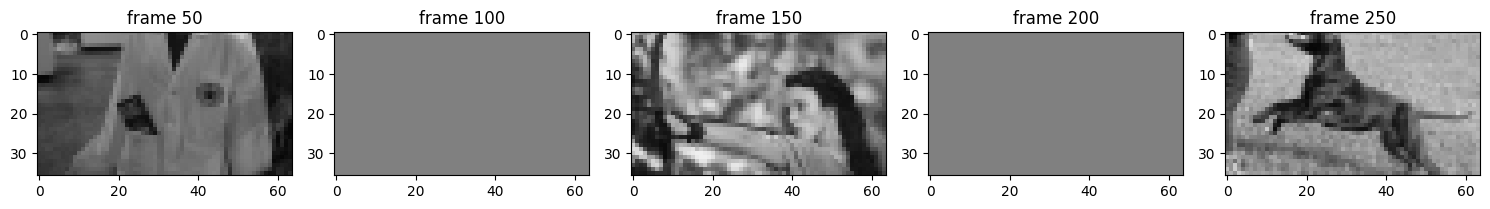

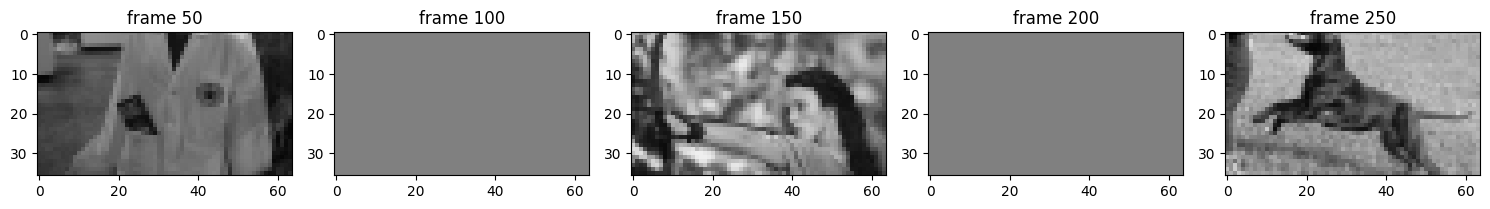

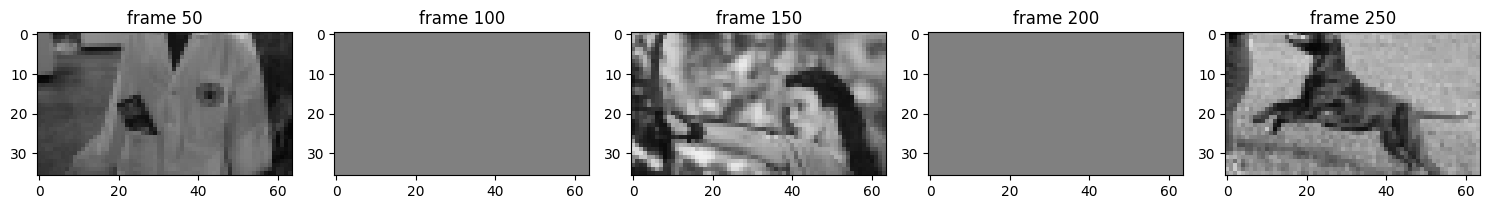

In [57]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='708', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='670', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='648', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)

In [58]:
ID = "v874315"
df_filtered = ds.filter_trials(ID=ID)
df_filtered

,recording,label,ID,trial,trial_type,valid_frames,valid_trial,valid_frames_video,valid_frames_response,valid_frames_diff
2344,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,702,live_test_main,305,True,305,305,0
2455,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,719,train,305,True,305,305,0
2648,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,689,train,305,True,305,305,0
2690,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,685,final_test_bonus,306,True,306,306,0
2830,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,693,live_test_bonus,306,True,306,306,0
2832,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,705,live_test_bonus,306,True,306,306,0
2840,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,717,live_test_bonus,305,True,305,305,0
2847,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,681,live_test_bonus,305,True,305,305,0
5765,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v874315,314,oracle,306,True,306,326,-20
5820,dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b...,NaturalImages,v874315,693,train,305,True,305,326,-21


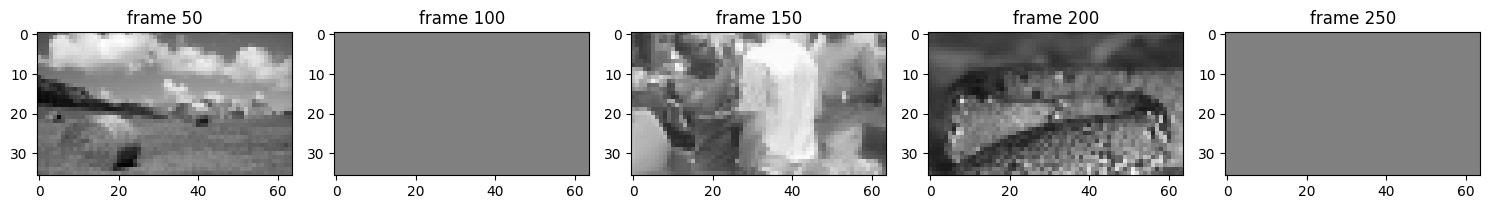

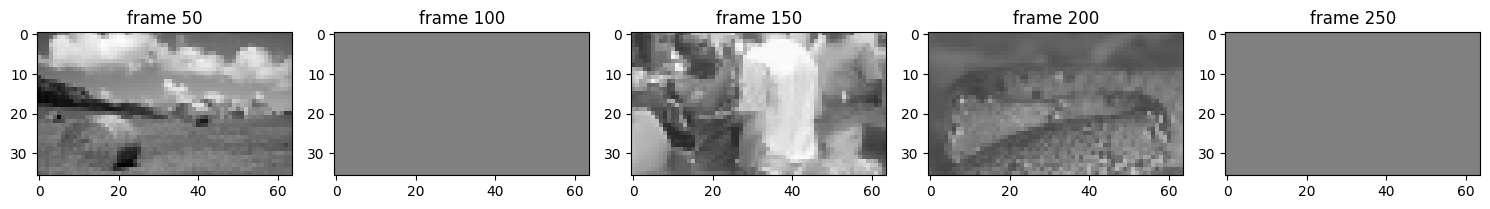

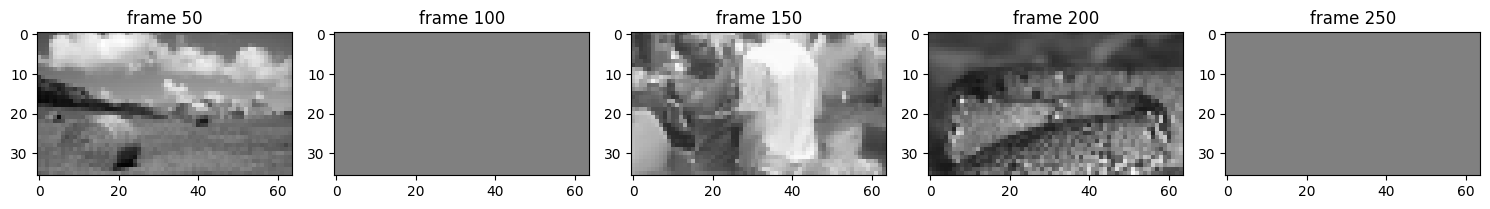

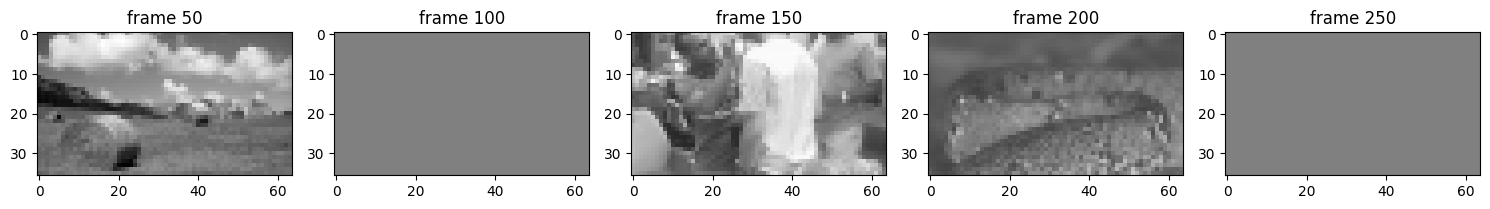

In [59]:
video_1 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='702', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_2 = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='685', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_3 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='647', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)
video_4 = ds.load_video_by_trial(recording='dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20', trial='534', load_metadata_from_dataframe=False, load_metadata_from_global_video=False)

frames_plot = np.arange(50, 300, 50).tolist()
fig, ax = video_1.plot_frames(frames_plot)
fig, ax = video_2.plot_frames(frames_plot)
fig, ax = video_3.plot_frames(frames_plot)
fig, ax = video_4.plot_frames(frames_plot)